<a href="https://colab.research.google.com/github/DanendraPassadhi/PCVK/blob/main/PCVK_Week09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## C.2 Global Threshold

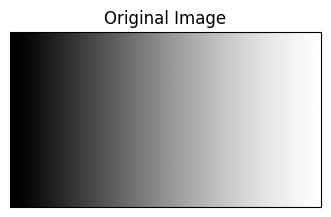

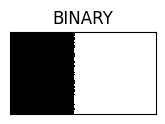

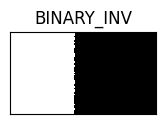

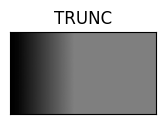

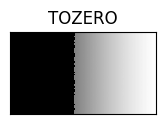

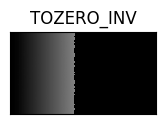

In [6]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt

filename = ('/content/drive/MyDrive/PCVK/gradient.jpg')
img = cv.imread(filename)
thresh = 127 #nilai Threshold yang ditentukan

#1. thresh1 jika pixel di img>127, maka thresh1 bernilai 1 (putih) selain itu bernilai 0 (hitam)
ret,thresh1 = cv.threshold(img,thresh,255,cv.THRESH_BINARY)
#2. thresh2 adalah binary threshold inverse
ret,thresh2 = cv.threshold(img,thresh,255,cv.THRESH_BINARY_INV)
#3. Threshold Truncate
ret,thresh3 = cv.threshold(img,thresh,255,cv.THRESH_TRUNC)
#4. Threshold Tozero
ret,thresh4 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO)
#5. Threshold Tozero Inverse
ret,thresh5 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO_INV)

titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

plt.figure(figsize = (15,5))
for i in range(len(images)):
    plt.subplot(2,3,i+1), plt.imshow(images[i],'gray', interpolation='nearest')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
    plt.show()

## C.3 Adaptive Threshold

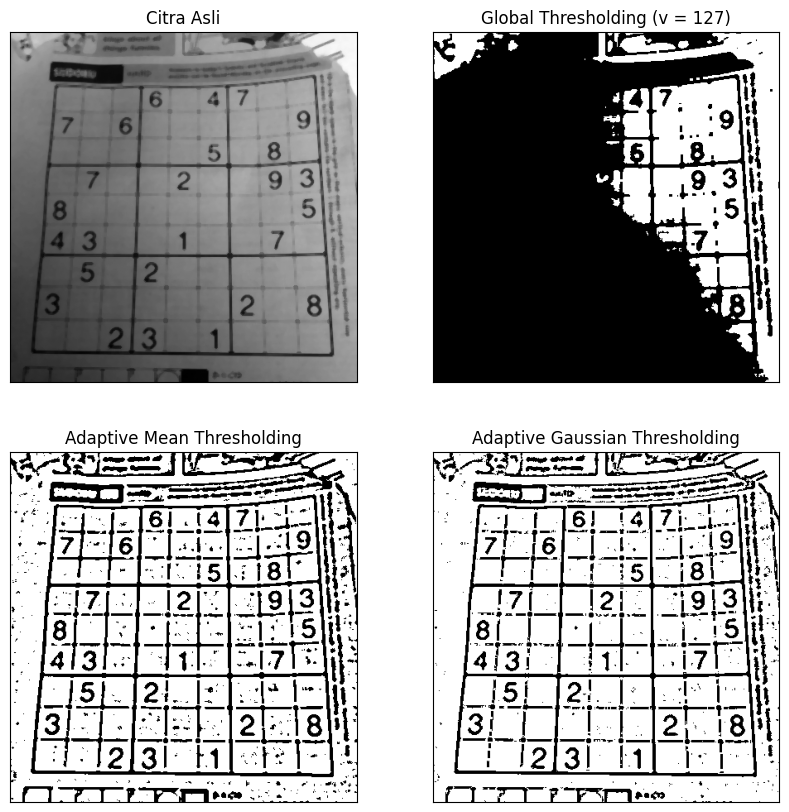

In [7]:
filename = ('/content/drive/MyDrive/PCVK/sudoku-original.jpg')
citra = cv.medianBlur(cv.imread(filename),5)
gray = cv.cvtColor(citra, cv.COLOR_BGR2GRAY)
#gray = cv.medianBlur(gray,5)

thresh = 127

ret,th1 = cv.threshold(gray,thresh,255,cv.THRESH_BINARY)
th2 = cv.adaptiveThreshold(gray,255,cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY,11,2)
th3 = cv.adaptiveThreshold(gray,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY,11,2)
titles = ['Citra Asli', 'Global Thresholding (v = 127)','Adaptive Mean Thresholding', 'Adaptive Gaussian Thresholding']
citra2 = [gray, th1, th2, th3]

plt.figure(figsize = (10,10))
for i in range(len(citra2)):
    plt.subplot(2,2,i+1),plt.imshow(citra2[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

## C.4 Otsu’s Threshold

/tmp/ipython-input-691378920.py:15: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(2,2,1),plt.hist(blur.ravel(),256,[50,200])


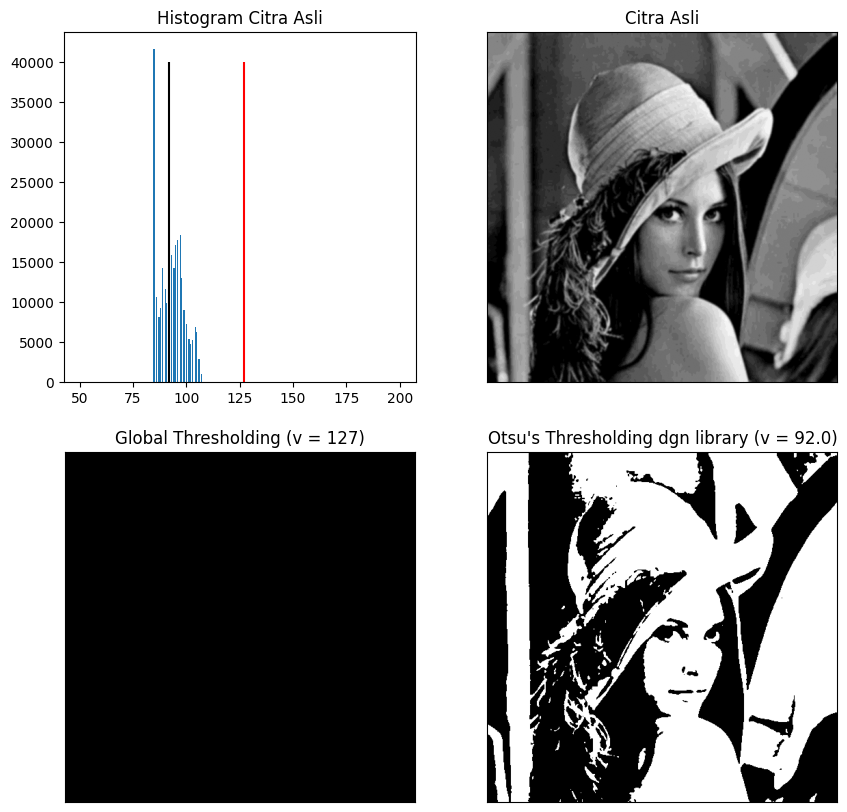

In [8]:
# Dengan Library
filename = ('/content/drive/MyDrive/PCVK/lena_gs_lc2.jpg')
img = cv.imread(filename,0)
blur = cv.GaussianBlur(img,(5,5),0)
thresh = 127

ret,th1 = cv.threshold(blur,thresh,255,cv.THRESH_BINARY)
ret2,th2 = cv.threshold(blur,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)

x = ("Otsu's Thresholding dgn library (v = ")+str(ret2)+")"
titles = ['Citra Asli', 'Global Thresholding (v = 127)', x]
citra3 = [blur, th1, th2]

plt.figure(figsize = (10,10))
plt.subplot(2,2,1),plt.hist(blur.ravel(),256,[50,200])
plt.vlines(ret,0,40000,colors='red') #garis vertikal merah menunjukan threshold global 127
plt.vlines(ret2,0,40000,colors='black') #garis vertikal hitam menunjukkan threshold 92 hasil otsu's
plt.title('Histogram Citra Asli')
for i in range(len(citra3)):
    plt.subplot(2,2,i+2),plt.imshow(citra3[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

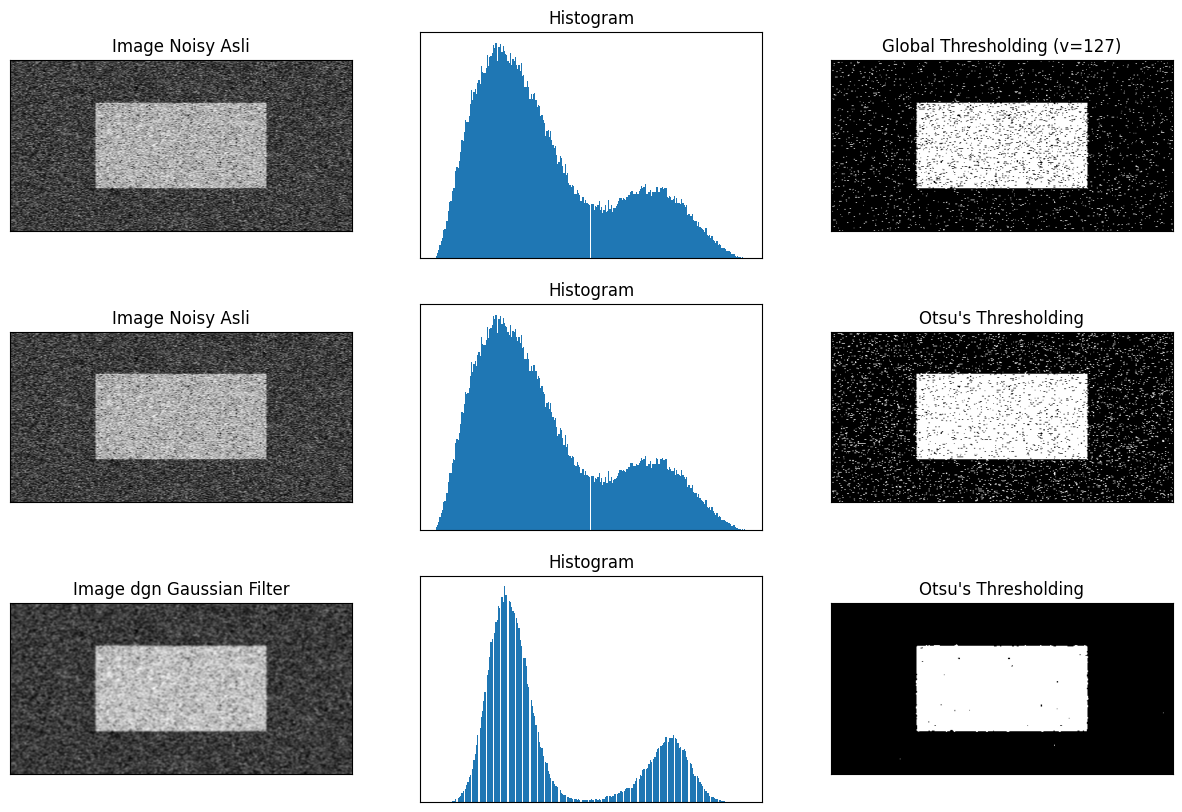

In [9]:
filename = ('/content/drive/MyDrive/PCVK/noisy2.png')
img = cv.imread(filename,0)

#Global Thresholding
ret1,th1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
# Otsu's thresholding
ret2,th2 = cv.threshold(img,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
# Otsu's thresholding setelah dilakukan Gaussian filtering
blur = cv.GaussianBlur(img,(5,5),0)
ret3,th3 = cv.threshold(blur,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
#plotting semua image
images = [img, 0, th1, img, 0, th2, blur, 0, th3]
titles = ['Image Noisy Asli','Histogram','Global Thresholding (v=127)',
'Image Noisy Asli','Histogram',"Otsu's Thresholding",
'Image dgn Gaussian Filter','Histogram',"Otsu's Thresholding"]
plt.figure(figsize = (15,10))
for i in range(3):
    plt.subplot(3,3,i*3+1),plt.imshow(images[i*3],'gray')
    plt.title(titles[i*3]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+2),plt.hist(images[i*3].ravel(),256)
    plt.title(titles[i*3+1]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+3),plt.imshow(images[i*3+2],'gray')
    plt.title(titles[i*3+2]), plt.xticks([]), plt.yticks([])
plt.show()

## C.5 Sementasi Citra menggunakan K-Means

(<Axes: >, <matplotlib.image.AxesImage at 0x7e11ff6f6e10>)

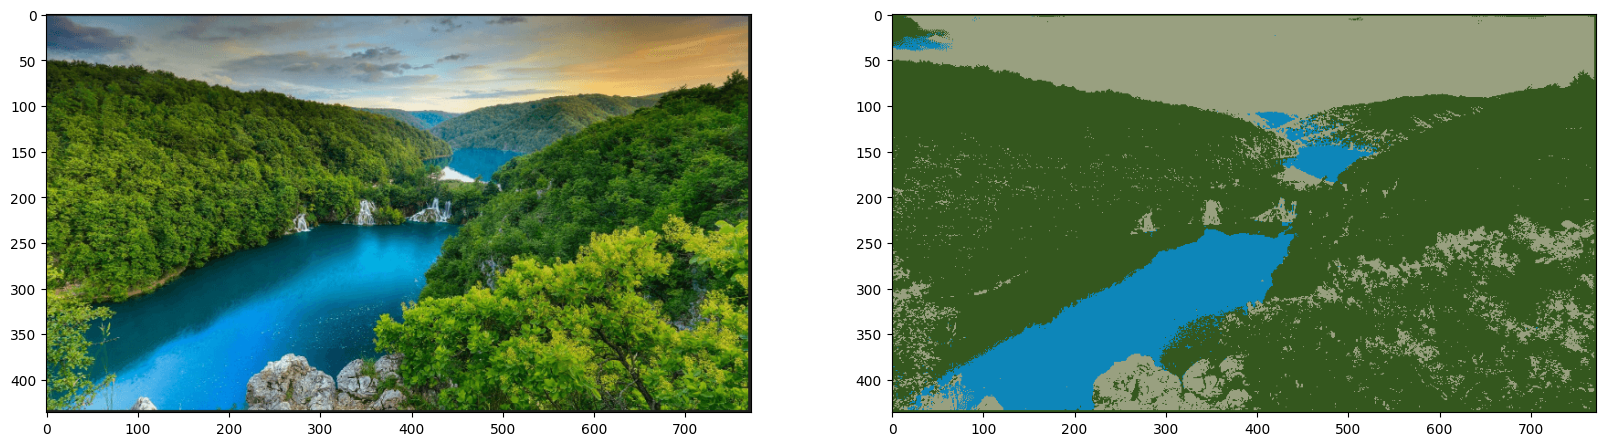

In [10]:
#KMeans Image Segmentation
filename = ('/content/drive/MyDrive/PCVK/jungle.png')
img = cv.imread(filename)
img = cv.cvtColor(img,cv.COLOR_BGR2RGB)
'''
kita akan menggunakan fungsi cv.kmeans() yang meminta array 2D sebagai masu
kan, sedangkan image aslinya adalah array 3D
selanjutnya kita perlu melakukan flattening array image masukan
'''
#reshape array ke bentuk 2D
pixel_values = img.reshape((-1, 3))
# convert to float
pixel_values = np.float32(pixel_values)
'''
syarat berhenti iterasi dr KMeans adalah jika centroid sudah tidak terlalu
banyak pergeseran posisi antara interasi sekarang
dengan iterasi sebelumnya (konvergen). Karena jumlah data yang besar, maka
kita akan hentikan iterasi saat jumlah iterasi = 100
atau epsilon(selisih antara posisi centroid skrg dgn posisi centroid di ite
rasi sebelumnya) < 0.2
'''
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)
'''
jika diperhatikan pada image asli, terdapat 3 warna utama (hijau, biru, dan
putih/orange). untuk percobaan ini kita akan gunakan
3 cluster untuk image ini
'''
k = 3
_, labels, (centers) = cv.kmeans(pixel_values, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)
#konversi titik centroid kedalam integer
centers = np.uint8(centers)
#flattening label array
labels = labels.flatten()
#konversi warna pixel asli kewarna dari tiap centroidnya
segmented_image = centers[labels.flatten()]
# reshape ke bentuk image asli
segmented_image = segmented_image.reshape(img.shape)
plt.figure(figsize = (20,20))
plt.subplot(1,2,1),plt.imshow(img)
plt.subplot(1,2,2),plt.imshow(segmented_image)

# D. Tugas Praktikum

### Import Library

In [11]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

### Global Threshold

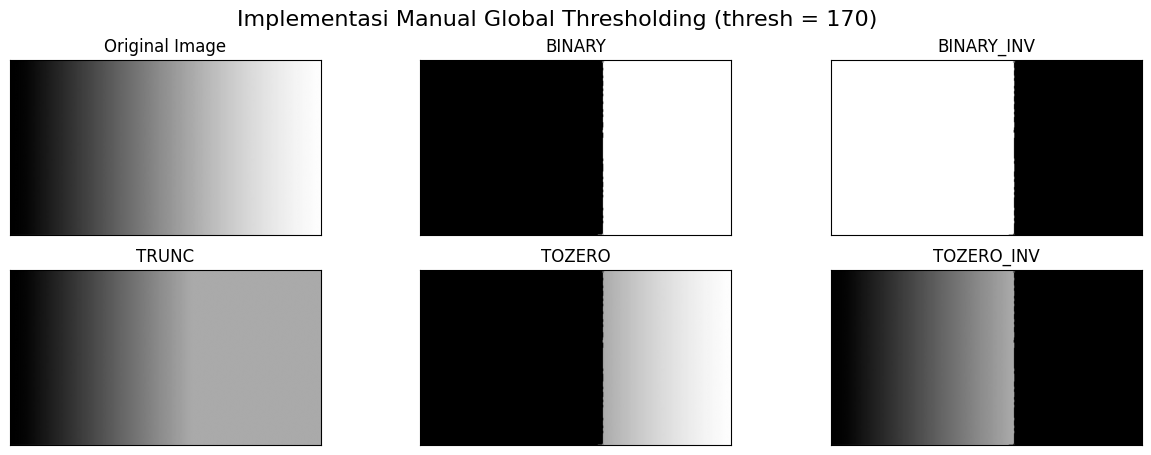

In [12]:
filename = ('/content/drive/MyDrive/PCVK/gradient.jpg')
img = cv2.imread(filename, 0)

thresh = 170
maxval = 255

# 1. BINARY
ret, thresh1_cv = cv2.threshold(img, thresh, maxval, cv2.THRESH_BINARY)
thresh1_manual = np.where(img > thresh, maxval, 0).astype(np.uint8)

# 2. BINARY_INV
ret, thresh2_cv = cv2.threshold(img, thresh, maxval, cv2.THRESH_BINARY_INV)
thresh2_manual = np.where(img > thresh, 0, maxval).astype(np.uint8)

# 3. TRUNC
ret, thresh3_cv = cv2.threshold(img, thresh, maxval, cv2.THRESH_TRUNC)
thresh3_manual = np.where(img > thresh, thresh, img).astype(np.uint8)

# 4. TOZERO
ret, thresh4_cv = cv2.threshold(img, thresh, maxval, cv2.THRESH_TOZERO)
thresh4_manual = np.where(img > thresh, img, 0).astype(np.uint8)

# 5. TOZERO_INV
ret, thresh5_cv = cv2.threshold(img, thresh, maxval, cv2.THRESH_TOZERO_INV)
thresh5_manual = np.where(img > thresh, 0, img).astype(np.uint8)

# Plotting
titles = ['Original Image', 'BINARY', 'BINARY_INV',
          'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1_manual, thresh2_manual,
          thresh3_manual, thresh4_manual, thresh5_manual]

plt.figure(figsize=(15, 5))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], 'gray', vmin=0, vmax=255)
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])

plt.suptitle(f'Implementasi Manual Global Thresholding (thresh = {thresh})', fontsize=16)
plt.show()

### Otsu Thresholding

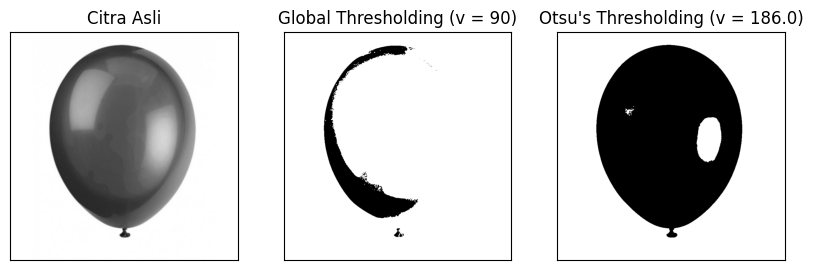

In [41]:
filename = ('/content/drive/MyDrive/PCVK/balloon.jpg')
img = cv.imread(filename,0)
blur = cv.GaussianBlur(img,(5,5),0)
thresh = 90

ret,th1 = cv.threshold(blur,thresh,255,cv.THRESH_BINARY)
ret2,th2 = cv.threshold(blur,186,255,cv.THRESH_BINARY)

x = ("Otsu's Thresholding (v = ")+str(ret2)+")"
titles = ['Citra Asli', 'Global Thresholding (v = 90)', x]
citra3 = [blur, th1, th2]

plt.figure(figsize = (10,10))
for i in range(len(citra3)):
    plt.subplot(1,3,i+1),plt.imshow(citra3[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

###  Histogram dari Citra Tersegmentasi

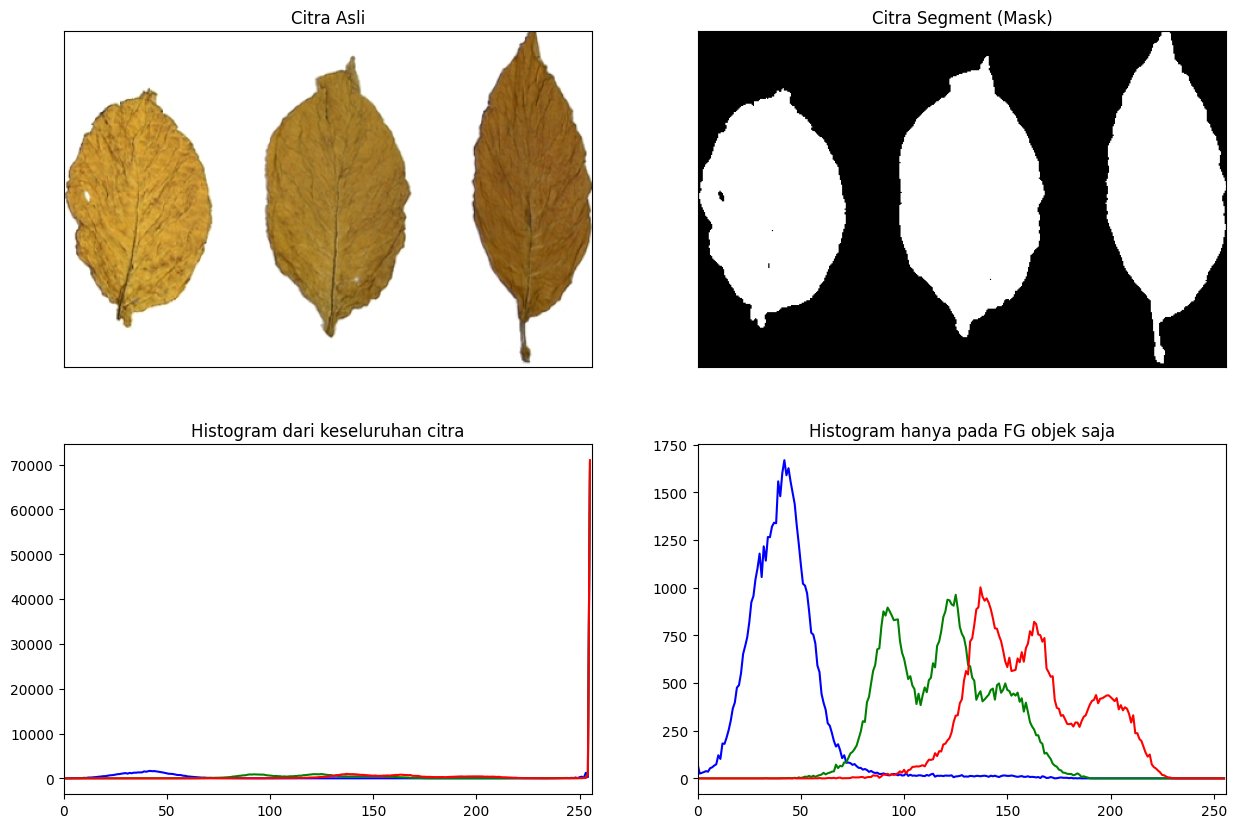

In [42]:
img_path = ('/content/drive/MyDrive/PCVK/tobacco.jpg')
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"File not found at {img_path}")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 1. Buat mask ("Citra Segment")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Menggunakan Otsu's thresholding.
ret, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 2. Hitung histogram
color = ('b', 'g', 'r')

# 2a. Histogram dari keseluruhan citra
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title('Citra Asli')
plt.xticks([]), plt.yticks([])

plt.subplot(2, 2, 3)
for i, col in enumerate(color):
    hist_full = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(hist_full, color=col)
plt.title('Histogram dari keseluruhan citra')
plt.xlim([0, 256])

# 2b. Histogram hanya pada FG objek saja
plt.subplot(2, 2, 2)
plt.imshow(mask, 'gray')
plt.title('Citra Segment (Mask)')
plt.xticks([]), plt.yticks([])

plt.subplot(2, 2, 4)
for i, col in enumerate(color):
    hist_masked = cv2.calcHist([img], [i], mask, [256], [0, 256])
    plt.plot(hist_masked, color=col)
plt.title('Histogram hanya pada FG objek saja')
plt.xlim([0, 256])
plt.show()

### Segmentasi Warna

Cluster 0: [250 206   4]
Cluster 1: [176 131  82]
Cluster 2: [143  42  18]
Cluster 3: [252 250 248]


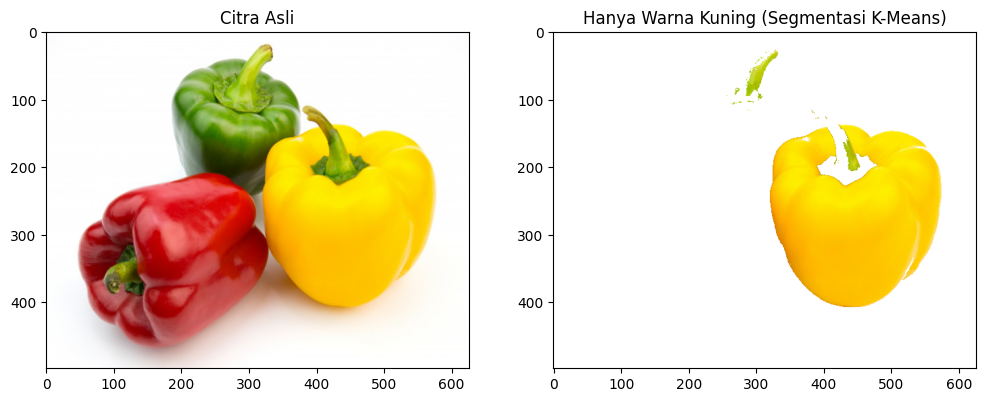

In [48]:
img_path = ('/content/drive/MyDrive/PCVK/peppers.jpg')
img = cv2.imread(img_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 1. Reshape dan konversi tipe data
pixel_values = img_rgb.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# 2. Terapkan K-Means
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
k = 4
compactness, labels, (centers) = cv2.kmeans(pixel_values, k, None,
                                            criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# Konversi centers ke uint8
centers = np.uint8(centers)

# 3. Identifikasi cluster kuning
yellow_cluster_index = -1
min_dist_to_yellow = float('inf')

# Warna kuning ideal (R, G, B)
ideal_yellow = np.array([255, 255, 0])

for i, center in enumerate(centers):
    print(f"Cluster {i}: {center}")
    dist = np.linalg.norm(center - ideal_yellow)
    if dist < min_dist_to_yellow:
        min_dist_to_yellow = dist
        yellow_cluster_index = i

# 4. Buat masked image
masked_image = np.copy(img_rgb)
# Reshape ke 2D
masked_image_2d = masked_image.reshape((-1, 3))
# Ubah semua piksel yang BUKAN cluster kuning menjadi putih
masked_image_2d[labels.flatten() != yellow_cluster_index] = [255, 255, 255]
# Reshape kembali ke bentuk citra asli
masked_image = masked_image_2d.reshape(img_rgb.shape)

# 5. Plotting
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Citra Asli')

plt.subplot(1, 2, 2)
plt.imshow(masked_image)
plt.title('Hanya Warna Kuning (Segmentasi K-Means)')
plt.show()

###  Thresholding Biner

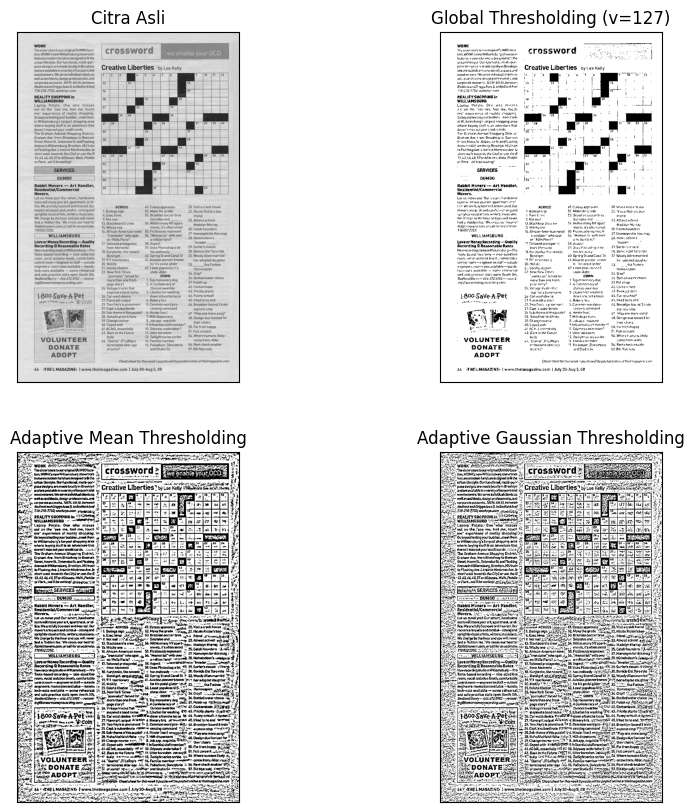

In [51]:
img_path = ('/content/drive/MyDrive/PCVK/crossword.jpg')
img = cv2.imread(img_path, 0)

# 1. Global Thresholding (v=127)
ret, th1 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# 2. Adaptive Mean Thresholding
th2 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                            cv2.THRESH_BINARY, 11, 2)

# 3. Adaptive Gaussian Thresholding
th3 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                            cv2.THRESH_BINARY, 11, 2)

# Plotting perbandingan
titles = ['Citra Asli', 'Global Thresholding (v=127)',
          'Adaptive Mean Thresholding', 'Adaptive Gaussian Thresholding']
images = [img, th1, th2, th3]

plt.figure(figsize=(10, 10))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()